In [27]:
import math
import matplotlib.colors as mcolors
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np

from enum import Enum
from itertools import product
from scipy.signal import convolve2d

img_path = "profile_pic_2020_1000x1000.png"

def find_min_max(kernel):
    min = float("inf")
    max = float("-inf")

    for row in kernel:
        for v in row:
            if v < min:
                min = v
            if v > max:
                max = v

    return (min, max)

def make_gradient(kernel):
    min, max = find_min_max(kernel)

    if min <= 0 & 0 <= max:
        center = 0
        gradient = ["#ef0044", "#ffffff", "#2aff24"]
    else:
        center = 0.5*(min+max)
        gradient = ["#ef0044", "#2aff24"]

    neg = "#0546ff"
    ctr = "#ffffff"
    pos = "#fffd07"

    if max <= 0:
        gradient = [neg, ctr]
    elif min >= 0:
        gradient = [ctr, pos]
    else:
        gradient = [neg, ctr, pos]

    norm = mcolors.TwoSlopeNorm(vmin=min, vcenter=center, vmax=max)
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "custom_gradient",
        gradient
    )

    return (norm, cmap)


def plot_kernel(kernel):
    norm, cmap = make_gradient(kernel)
    plt.imshow(kernel, norm=norm, cmap=cmap)
    plt.colorbar()
    plt.show()

def apply_and_plot(kernel, img):
    kernel = normalize(kernel)
    img = normalize(img)

    out = convolve2d(img, kernel, mode='same')
    img[:kernel.shape[0], :kernel.shape[1]] = kernel

    fig, axes = plt.subplots(1, 2)
    axes[0].imshow(img, cmap="gray")
    axes[1].imshow(out, cmap="gray")
    plt.show()

def normalize(img):
    arr = np.array(img)
    normalized = (arr - arr.min()) / (arr.max() - arr.min())
    return normalized

(A)


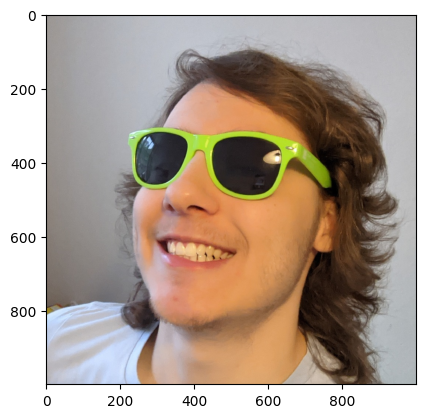

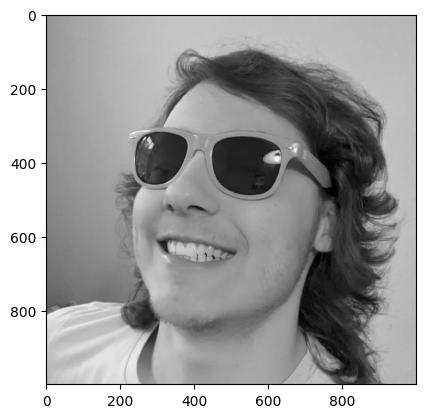

In [23]:
# Excercise 4. (A)
print("(A)")

img = mpimg.imread(img_path)
plt.imshow(img)
plt.show()

# prepare image
if img.ndim == 3:
    img = img.mean(axis=2)

plt.imshow(img, cmap="gray")
plt.show()

(B)
L: 40
v: 5


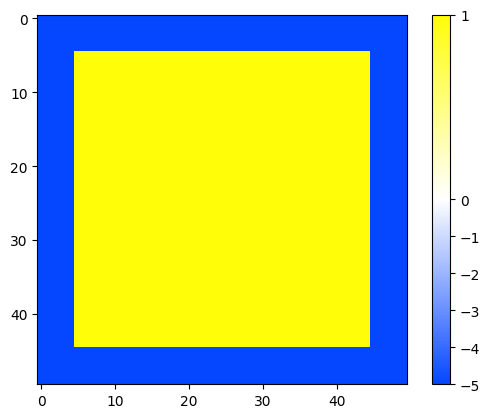

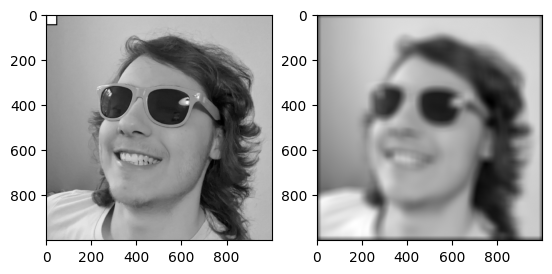

L: 25
v: 10


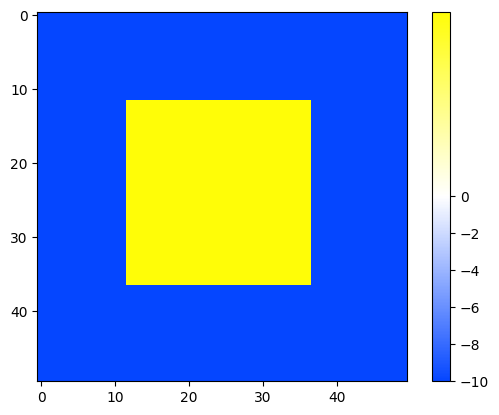

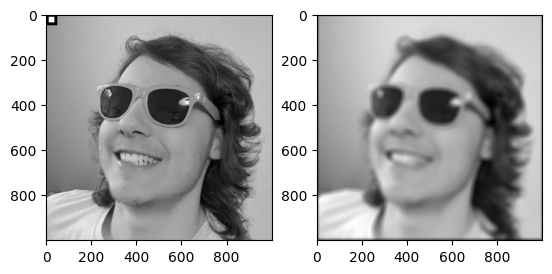

L: 25
v: -10


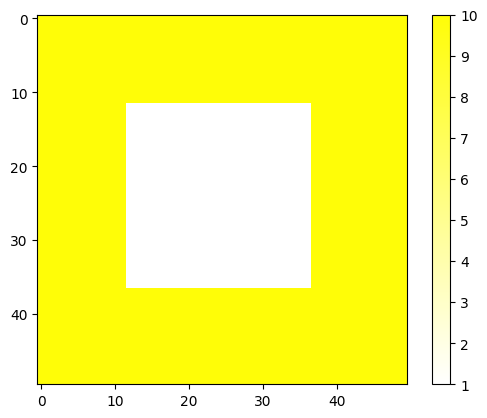

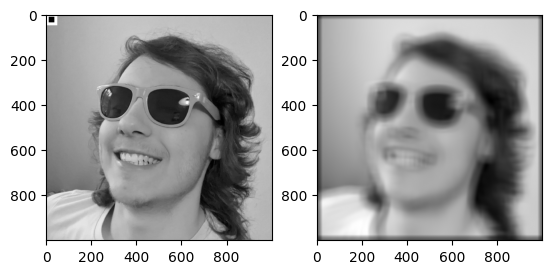

L: 2
v: 10


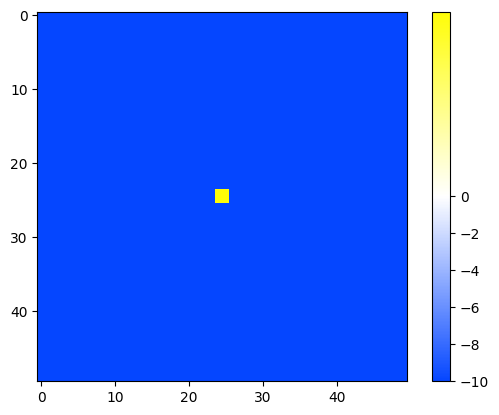

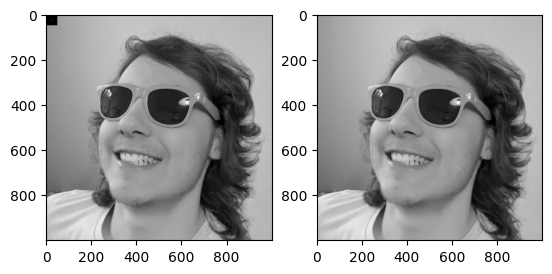

In [24]:
# Excercise 4. (B)
print("(B)")


# define helper class and function
class Parameter:
    def __init__(self, kernel_width, L, v):
        self.kernel_width = kernel_width
        self.L = L
        self.v = v

def make_box_kernel(kernel_width, L, v):
    kernel = np.ones((kernel_width,kernel_width)) * -v
    min = int((kernel_width - L) / 2)
    max = int((kernel_width + L) / 2)
    kernel[min:max, min:max] = 1
    return kernel

# define parameters
N = 50
parameters = [
    Parameter(N, L=40, v=5),
    Parameter(N, L=25, v=10),
    Parameter(N, L=25, v=-10),
    Parameter(N, L=2, v=10),
]

# generate, apply kernel and plot resulting image
for p in parameters:
    kernel_width = p.kernel_width
    L = p.L
    v = p.v

    print(f"L: {L}")
    print(f"v: {v}")
    
    kernel = make_box_kernel(kernel_width, L, v)
    plot_kernel(kernel)
    apply_and_plot(kernel, img)

(C)
wc: 1.1
oc: 8
ws: 1
os: 40


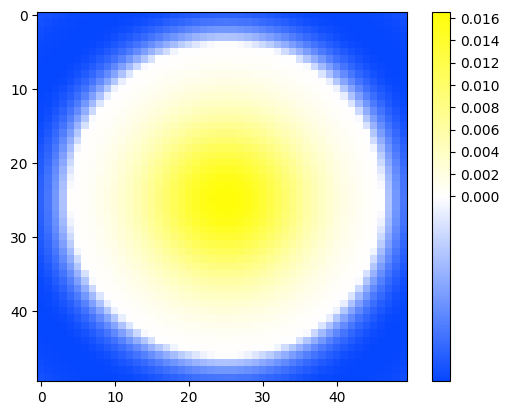

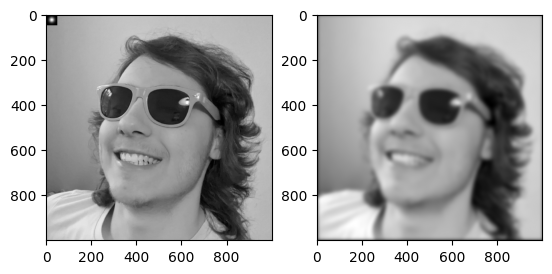

wc: 1
oc: 40
ws: 1.1
os: 8


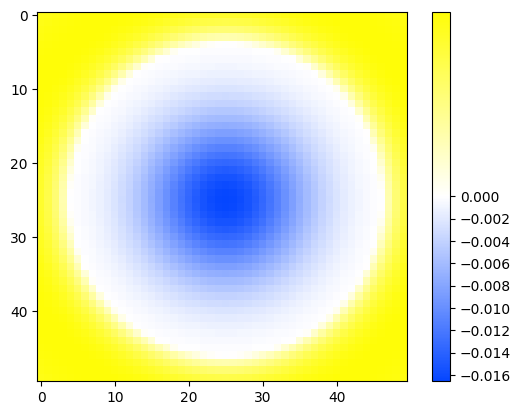

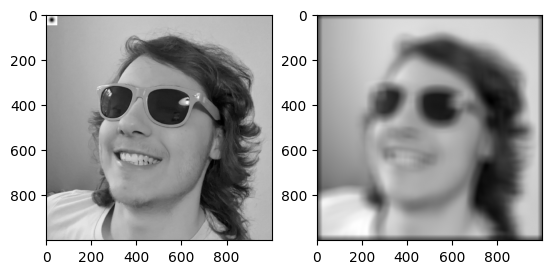

wc: 4.4
oc: 1.5
ws: 6.2
os: 5


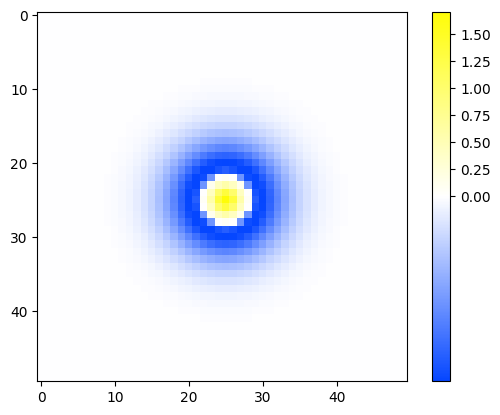

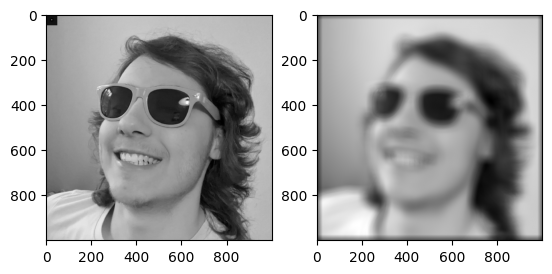

wc: 4.8
oc: 3
ws: 3.5
os: 1.8


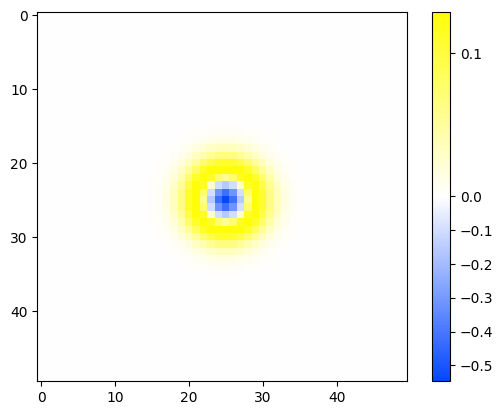

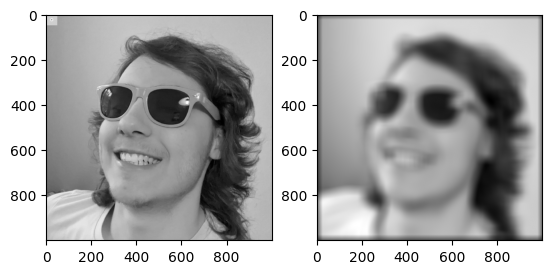

In [25]:
# Excercise 4. (C)
print("(C)")

# define helper class and function
class Parameter:
    def __init__(self, kernel_width, wc, oc, ws, os):
        self.kernel_width = kernel_width
        self.wc = wc
        self.oc = oc
        self.ws = ws
        self.os = os

# https://www.desmos.com/calculator/ytrkggiqib
def make_gaussian_kernel(p: Parameter):
    kernel = np.zeros((p.kernel_width, p.kernel_width))

    for iy in range(p.kernel_width):
        for ix in range(p.kernel_width):
            x = ix - int(p.kernel_width / 2)
            y = iy - int(p.kernel_width / 2)

            x2 = x * x
            y2 = y * y
            x2y2 = x2 + y2
            wc = p.wc
            ws = p.ws
            oc = p.oc
            os = p.os
            oc2 = oc * oc
            os2 = os * os

            k1 = (wc / oc2) * math.exp(- x2y2 / (2 * oc2))
            k2 = (ws / os2) * math.exp(- x2y2 / (2 * os2))
            k = k1 - k2

            kernel[ix, iy] = k

    return kernel

# define parameters
N = 50
parameters = [
    Parameter(N, wc=1.1, oc=8, ws=1, os=40),
    Parameter(N, wc=1, oc=40, ws=1.1, os=8),
    Parameter(N, wc=4.4, oc=1.5, ws=6.2, os=5),
    Parameter(N, wc=4.8, oc=3, ws=3.5, os=1.8),
]

# generate, apply kernel and plot resulting image
for p in parameters:
    print(f"wc: {p.wc}")
    print(f"oc: {p.oc}")
    print(f"ws: {p.ws}")
    print(f"os: {p.os}")
    
    kernel = make_gaussian_kernel(p)
    plot_kernel(kernel)
    apply_and_plot(kernel, img)

# explanation
# sigma o controls the width of the gaussian, omega w the weight or amplitude

(D) + (E)
ox: 3.0
oy: 4.5
k: 0.2
phi: 1.5707963267948966


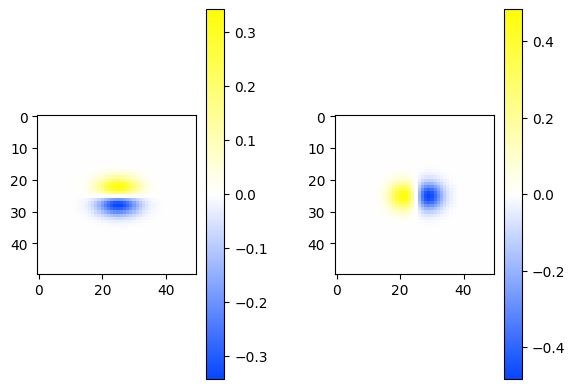

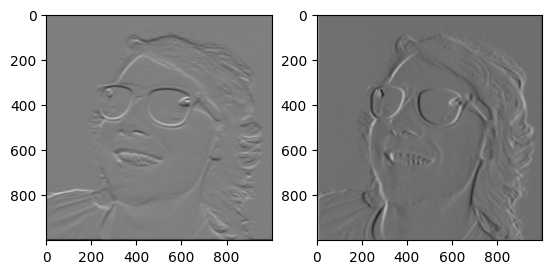

ox: 6
oy: 9
k: 0.2
phi: 3.141592653589793


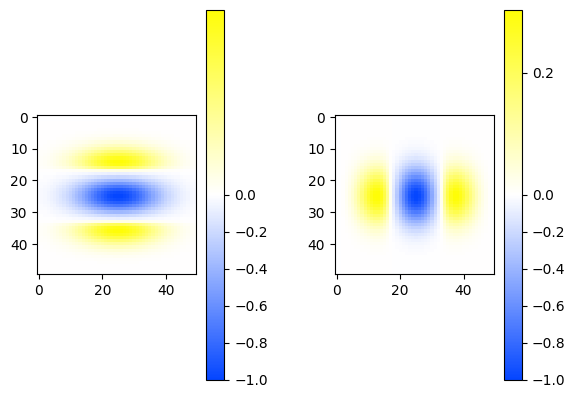

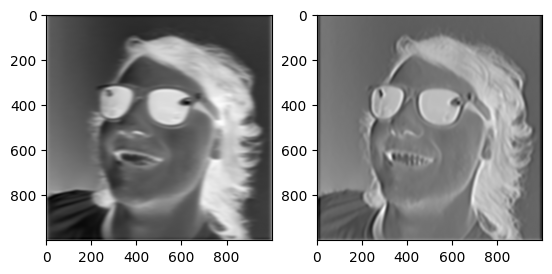

ox: 6
oy: 9
k: 0.5
phi: 0


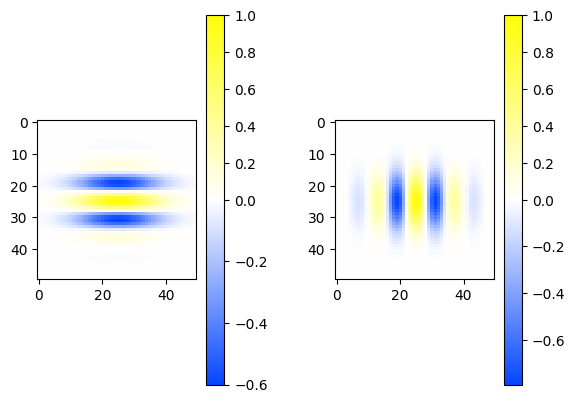

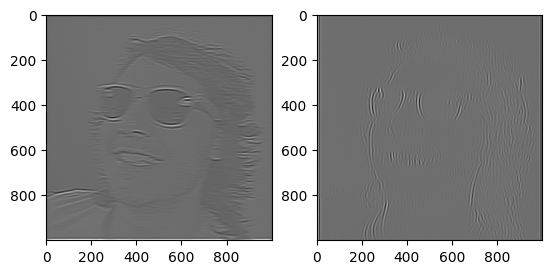

In [28]:
# Excercise 4. (D) + (E)
print("(D) + (E)")

# define helper class and function
class Orientation(Enum):
    HORIZONTAL = 1
    VERTICAL = 2

class Parameter:
    def __init__(
        self,
        kernel_width,
        ox,
        oy,
        k,
        phi,
    ):
        self.kernel_width = kernel_width
        self.ox = ox
        self.oy = oy
        self.k = k
        self.phi = phi

# https://www.desmos.com/calculator/qg2mdr2mqz
def make_receptive_field_kernel(p: Parameter, orientation):
    kernel = np.zeros((p.kernel_width, p.kernel_width))

    for iy in range(p.kernel_width):
        for ix in range(p.kernel_width):
            x = ix - int(p.kernel_width / 2)
            y = iy - int(p.kernel_width / 2)

            ox = p.ox
            oy = p.oy
            k = p.k
            phi = p.phi

            if orientation == Orientation.VERTICAL:
                val = x
            else:
                val = y
            
            exp = math.exp(-((x*x)/(2*ox*ox))-((y*y)/(2*oy*oy)))
            cos = math.cos(k * val + phi)
            k = exp * cos

            kernel[ix, iy] = k

    return kernel

# define parameters
parameters = [
    Parameter(50, ox=3.0, oy=4.5, k=0.2, phi=math.pi/2),
    Parameter(50, ox=6, oy=9, k=0.2, phi=math.pi),
    Parameter(50, ox=6, oy=9, k=0.5, phi=0),
]

# generate, apply kernel and plot resulting image
for p in parameters:
    print(f"ox: {p.ox}")
    print(f"oy: {p.oy}")
    print(f"k: {p.k}")
    print(f"phi: {p.phi}")
    
    kernel_vertical = make_receptive_field_kernel(p, Orientation.VERTICAL)
    kernel_horizontal = make_receptive_field_kernel(p, Orientation.HORIZONTAL)

    # plot kernel
    fig, axes = plt.subplots(1, 2)

    #min, max = find_min_max(kernel_vertical)
    #im0 = axes[0].imshow(kernel_vertical, vmin=min, vmax=max)
    #fig.colorbar(im0, ax=axes[0])
#
    #min, max = find_min_max(kernel_horizontal)
    #im1 = axes[1].imshow(kernel_horizontal, vmin=min, vmax=max)
    #fig.colorbar(im1, ax=axes[1])

    norm, cmap = make_gradient(kernel_vertical)
    im0 = axes[0].imshow(kernel_vertical, norm=norm, cmap=cmap)
    fig.colorbar(im0, ax=axes[0])

    norm, cmap = make_gradient(kernel_horizontal)
    im1 = axes[1].imshow(kernel_horizontal, norm=norm, cmap=cmap)
    fig.colorbar(im1, ax=axes[1])

    fig.subplots_adjust(wspace=0.5)

    plt.show()

    # apply kernel and plot image
    fig, axes = plt.subplots(1, 2)

    out = convolve2d(img, kernel_vertical, mode='same')
    axes[0].imshow(out, cmap="gray")
    out = convolve2d(img, kernel_horizontal, mode='same')
    axes[1].imshow(out, cmap="gray")

    plt.show()

# explanation
# sigma o controls the width of the gaussian, k the frequenzy of the wave, and phi the phase